In [1]:
%pwd

'd:\\Tipto\\OmniChef-Nexus\\notebooks'

In [2]:
import os 
os.chdir("../")

In [3]:
%pwd

'd:\\Tipto\\OmniChef-Nexus'

In [4]:
import warnings
warnings.filterwarnings('ignore' , category = FutureWarning)

In [5]:
import pandas as pd 
df = pd.read_csv("data/all csv files/recipes_15k_samples.csv")

In [6]:
df.shape

(15698, 15)

In [7]:
# taking 100 samples for now
df_sample_100 = df.sample(100).copy()

In [10]:
df_sample_100.head(4)

,name,minutes,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,recipe_id,rating,review,num of ratings,markdown_recipe,image_path
0,tuscan potato soup zuppa toscana,70,"['time-to-make', 'course', 'main-ingredient', ...","[444.0, 36.0, 13.0, 57.0, 38.0, 40.0, 12.0]",7,"['in a large stock pot combine the water , chi...",there are a number of recipes out there that t...,"['chicken broth', 'water', 'bacon', 'italian s...",15,228348,4.388889,"['Perfect!', ""I have this recipe and have used...",18.0,# Tuscan Potato Soup Zuppa Toscana\n**Recipe ...,data/output/images/recipe_id_228348.png
1,bacon cheeseburger macaroni skillet,35,"['60-minutes-or-less', 'time-to-make', 'course...","[677.8, 50.0, 34.0, 27.0, 76.0, 73.0, 18.0]",10,"['cook pasta according to package directions',...",i have found a great recipe! i can't believe ...,"['macaroni', 'onion', 'ground beef', 'tomato s...",9,187004,4.214286,['Well this is excellent and a big hit with my...,14.0,# Bacon Cheeseburger Macaroni Skillet\n**Recip...,data/output/images/recipe_id_187004.png
2,apple onion pork chops,50,"['60-minutes-or-less', 'time-to-make', 'course...","[339.2, 22.0, 20.0, 36.0, 46.0, 24.0, 9.0]",4,"['salt and pepper chops and quickly brown', 'm...",quick and easy and really good! this makes a n...,"['pork chops', 'applesauce', 'brown sugar', 'd...",5,30519,4.521739,['Very good and very easy. I am always looking...,23.0,# Apple Onion Pork Chops\n**Recipe ID:** 30519...,data/output/images/recipe_id_30519.png
3,red lobster cheddar bay biscuits copycat,18,"['30-minutes-or-less', 'time-to-make', 'course...","[280.5, 30.0, 15.0, 19.0, 10.0, 52.0, 7.0]",6,"['heat oven to 450 degrees', 'mix bisquick , m...","these are copycats of the delicious ""cheddar b...","['bisquick', 'milk', 'cheddar cheese', 'butter...",5,9494,4.324176,['These are just as good as Red Lobsters!!!!!!...,182.0,# Red Lobster Cheddar Bay Biscuits Copycat\n**...,data/output/images/recipe_id_9494.png


In [9]:
df_sample_100.reset_index(drop = True , inplace = True)

In [11]:
# also save this 100 samples for later use
df_sample_100.to_csv("data/all csv files/recipes_100_samples.csv")

In [12]:
df_sample_100.columns

Index(['name', 'minutes', 'tags', 'nutrition', 'n_steps', 'steps',
       'description', 'ingredients', 'n_ingredients', 'recipe_id', 'rating',
       'review', 'num of ratings', 'markdown_recipe', 'image_path'],
      dtype='str')

In [7]:
df.head(2)

,name,minutes,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,recipe_id,rating,review,num of ratings,markdown_recipe,image_path
0,chicken lickin good pork chops,500,"['weeknight', 'time-to-make', 'course', 'main-...","[105.7, 8.0, 0.0, 26.0, 5.0, 4.0, 3.0]",5,"['dredge pork chops in mixture of flour , salt...",here's and old standby i enjoy from time to ti...,"['lean pork chops', 'flour', 'salt', 'dry must...",7,63986,4.368421,"[""I made this for dinner tonight and the chops...",19.0,# Chicken Lickin Good Pork Chops\n**Recipe I...,data/output/images/recipe_id_63986.png
1,chile rellenos,45,"['60-minutes-or-less', 'time-to-make', 'course...","[94.0, 10.0, 0.0, 11.0, 11.0, 21.0, 0.0]",9,"['drain green chiles', 'sprinkle cornstarch on...",a favorite from a local restaurant no longer i...,"['egg roll wrap', 'whole green chilies', 'chee...",5,43026,4.045455,"['Grandma Pam, Oh my goodness,these were so ea...",22.0,# Chile Rellenos\n**Recipe ID:** 43026\n**Cook...,data/output/images/recipe_id_43026.png


In [8]:
import torch
from transformers import AutoModel , AutoProcessor
from transformers.image_utils import load_image
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
# load the embedding model with a specific revision version
model_name = "nvidia/llama-nemotron-embed-vl-1b-v2"
revision = "062ffaa1e3d24a8a50bd6a7ac7b8e54103e1f01d"

model = AutoModel.from_pretrained(
    model_name,
    revision = revision,
    dtype = torch.float16,
    trust_remote_code = True,
    attn_implementation = "flash_attention_2",
    device_map = "auto"
).eval()

Loading weights:   0%|          | 0/600 [00:00<?, ?it/s]

In [10]:
# make a helper function to change the model's modality
def prepare_processor(modality , embedding_model):
    """Prepare the model for different modality.

    Args:
        modality (str): can be 'text' , 'image' or 'image_text'
        embedding_model (_type_): embedding model

    Returns:
        _type_: (modality , embedding_model)
    """
    # Set max number of tokens (p_max_length) based on modality
    if modality == "image":
        p_max_length = 2048
    elif modality == "image_text":
        p_max_length = 10240
    elif modality == "text":
        p_max_length = 8192
    embedding_model.processor.p_max_length = p_max_length
    # Image specific settings(only matter if image is present)
    # Sets max number of tiles an image can be split. Each tile consumes 256 tokens.
    embedding_model.processor.max_input_tiles = 6
    # Enables an extra tile with the full image at lower resolution
    embedding_model.processor.use_thumbnail = True
    return modality , embedding_model

In [17]:
# load the image of recipe cards for 100 samples
from pathlib import Path 

sample_100_image_paths = list(df_sample_100['image_path'])
sample_100_images = [
    load_image(path) for path in sample_100_image_paths
]
print(f"Total image loaded: {len(sample_100_images)}")

Total image loaded: 100


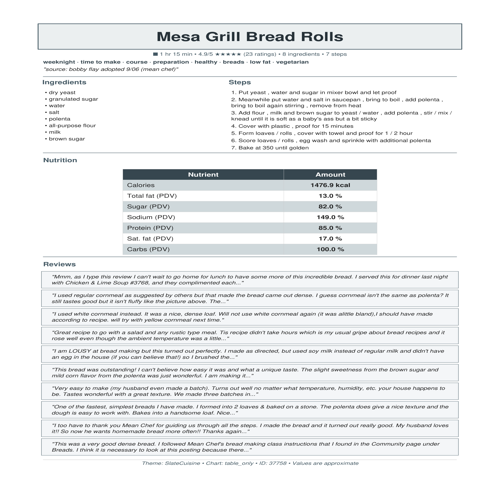

In [18]:
sample_100_images[42].resize((500 , 500))

In [19]:
# take a documents(markdown recipe text)
sample_100_recipe_texts = list(df_sample_100['markdown_recipe'])
print(f"Total recipe texts: {len(sample_100_recipe_texts)}")

Total recipe texts: 100


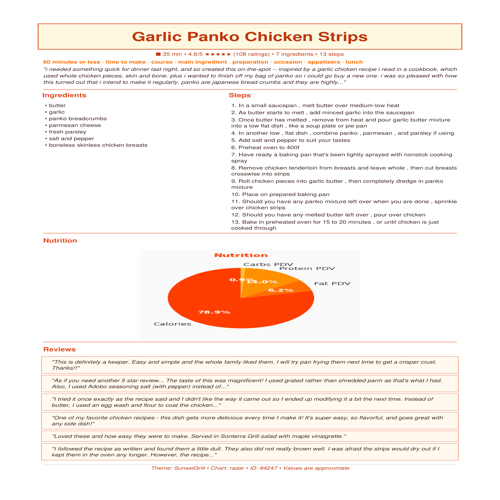

In [28]:
sample_100_images[23].resize(size = (500 , 500))

In [20]:
print(sample_100_recipe_texts[23])

# Garlic Panko Chicken Strips
**Recipe ID:** 84247
**Cook Time:** 35 minutes
**Rating:** 4.56/5 stars (108 reviews)

## Description
i needed something quick for dinner last night, and so created this on-the-spot -- inspired by a garlic chicken recipe i read in a cookbook, which used whole chicken pieces, skin and bone. plus i wanted to finish off my bag of panko so i could go buy a new one. i was so pleased with how this turned out that i intend to make it regularly. panko are japanese bread crumbs and they are highly superior to any other type; please try to source them out for this dish rather than use regular dry bread crumbs. the "international" or "ethnic" aisle in your grocery store should sell panko; if not, complain to the manager!

## Ingredients
butter, garlic, panko breadcrumbs, parmesan cheese, fresh parsley, salt and pepper, boneless skinless chicken breasts

## Instructions
1. In a small saucepan , melt butter over medium-low heat
2. As butter starts to melt , add minced 

### Try embedding for a single sample

In [21]:
# lets try a to embedd a single image

# set the model's modality to image
modality , model = prepare_processor(modality = 'image' , embedding_model = model)
model.processor.p_max_length

2048

In [22]:
with torch.inference_mode():
    image_sample_embedding = model.encode_documents(images = [sample_100_images[0]])

image_sample_embedding.shape

torch.Size([1, 2048])

In [23]:
# try a text only embedding
with torch.inference_mode():
    text_sample_embedding = model.encode_documents(texts = [sample_100_recipe_texts[0]])

text_sample_embedding.shape

torch.Size([1, 2048])

In [24]:
# try a text + image embedding
with torch.inference_mode():
    text_image_sample_embedding = model.encode_documents(
        texts = [sample_100_recipe_texts[0]] , images = [sample_100_images[0]] 
    )

text_image_sample_embedding.shape

torch.Size([1, 2048])

In [25]:
# pre-allocate CPU tensors for 100 samples

N = 100 # we will have 100 embedding vectors
D = 2048 # our embedding model produces 2048 dim vectors for each sample

# we are allowcating memory on cpu, cause our gpu can't hold all of them at once while calculating
embedding_text_100 = torch.empty(size = (N , D) , dtype = torch.float16)
embedding_image_100 = torch.empty(size = (N , D) , dtype = torch.float16)
embedding_image_text_100 = torch.empty(size = (N , D) , dtype = torch.float16)

### Let's do the text only embeddings for 100 samples

In [26]:
# set the modality to text only
modality , model = prepare_processor(modality = 'text' , embedding_model = model)
modality , model.processor.p_max_length

('text', 8192)

In [30]:
batch_size = 8 # set the batch size 8 for now

for start_index in range(0 , len(sample_100_recipe_texts) , batch_size):
    end_index = min(start_index + batch_size , len(sample_100_recipe_texts))
    batch_texts = sample_100_recipe_texts[start_index : end_index]
    
    with torch.inference_mode():
        # do the embedding
        batch_emb = model.encode_documents(texts = batch_texts)
        batch_emb = batch_emb.cpu().to(torch.float16)
    
    # store the current batch on preallocated memory
    embedding_text_100[start_index : end_index] = batch_emb
    # clean up
    del batch_emb
    torch.cuda.empty_cache() 

In [31]:
len(embedding_text_100)

100

In [33]:
embedding_text_100[0].shape

torch.Size([2048])

### Let's do the image only embeddings for 100 samples

In [34]:
# prepare the model for image modality
new_modality , model = prepare_processor(
    modality = "image" , embedding_model = model
)
model.processor.p_max_length

2048

In [35]:
len(sample_100_images)

100

In [36]:
batch_size = 8 # set the batch size 8 for now

for start_index in range(0 , len(sample_100_images) , batch_size):
    end_index = min(start_index + batch_size , len(sample_100_images))
    batch_image = sample_100_images[start_index : end_index]
    
    with torch.inference_mode():
        # do the embedding
        batch_emb = model.encode_documents(images = batch_image)
        batch_emb = batch_emb.cpu().to(torch.float16)
    
    # store the current batch on preallocated memory
    embedding_image_100[start_index : end_index] = batch_emb
    # clean up
    del batch_emb
    torch.cuda.empty_cache()   

In [37]:
embedding_image_100[0].shape

torch.Size([2048])

### Let's do the image only embeddings for 100 samples

In [38]:
# prepare the model for image + text modality
new_modality , model = prepare_processor(
    modality = "image_text" , embedding_model = model
)
model.processor.p_max_length

10240

In [41]:
%time

batch_size = 8 # set the batch size 8 for now

for start_index in range(0 , len(sample_100_images) , batch_size):
    end_index = min(start_index + batch_size , len(sample_100_images))
    
    # get the texts
    batch_texts = sample_100_recipe_texts[start_index : end_index]
    # get the images
    batch_image = sample_100_images[start_index : end_index]
    
    # print(f"Batch {start_index}: texts={len(batch_texts)}, images={len(batch_image)}")
    
    with torch.inference_mode():
        # do the embedding
        batch_emb = model.encode_documents(texts = batch_texts , images = batch_image)
        batch_emb = batch_emb.cpu().to(torch.float16)
    
    # store the current batch on preallocated memory
    embedding_image_text_100[start_index : end_index] = batch_emb
    # clean up
    del batch_emb
    torch.cuda.empty_cache()   

CPU times: total: 0 ns
Wall time: 4.05 μs


In [42]:
embedding_image_text_100

tensor([[-0.3667, -0.2712,  1.2334,  ...,  0.0279,  0.0693, -1.4873],
        [ 1.2217, -0.6362,  0.6890,  ..., -0.8354, -1.3359,  0.7139],
        [-1.3252,  1.7695,  3.7051,  ..., -1.2871, -2.3496, -1.2920],
        ...,
        [ 0.3496,  0.1954, -0.1522,  ..., -0.5264, -1.5273,  1.8506],
        [ 0.2196, -1.4512,  1.4189,  ...,  0.5620, -1.7559,  1.9639],
        [-0.1125, -0.8154,  0.2837,  ..., -2.3828, -1.3145,  1.2236]],
       dtype=torch.float16)

In [43]:
# save all the tensor as a safe tensor file
from safetensors.torch import save_file

In [44]:
# Create a dictionary mapping names to tensors
tensors_dict = {
    "text_embeddings": embedding_text_100,
    "image_embeddings": embedding_image_100,
    "image_text_embeddings": embedding_image_text_100
}

In [45]:
tensors_dict['image_text_embeddings']

tensor([[-0.3667, -0.2712,  1.2334,  ...,  0.0279,  0.0693, -1.4873],
        [ 1.2217, -0.6362,  0.6890,  ..., -0.8354, -1.3359,  0.7139],
        [-1.3252,  1.7695,  3.7051,  ..., -1.2871, -2.3496, -1.2920],
        ...,
        [ 0.3496,  0.1954, -0.1522,  ..., -0.5264, -1.5273,  1.8506],
        [ 0.2196, -1.4512,  1.4189,  ...,  0.5620, -1.7559,  1.9639],
        [-0.1125, -0.8154,  0.2837,  ..., -2.3828, -1.3145,  1.2236]],
       dtype=torch.float16)

In [46]:
tensors_dict['text_embeddings']

tensor([[-1.1270, -1.7861,  0.0439,  ...,  1.2402,  0.0970, -3.2754],
        [ 0.2135,  0.1197, -0.0784,  ..., -0.9604, -1.9502, -1.9893],
        [ 1.1543, -0.0608,  3.5449,  ..., -0.6289, -2.5547, -2.8730],
        ...,
        [-0.3247, -1.2217,  0.2812,  ..., -0.2517, -1.6426,  0.6997],
        [ 0.1884, -1.9912,  1.8008,  ...,  0.4241, -2.4590, -1.1484],
        [ 0.4827, -0.9731,  0.3669,  ..., -2.0117, -0.6846, -2.5820]],
       dtype=torch.float16)

In [47]:
# create the folder to store the embedding files
save_dir = "data/embedding_tensors"
os.makedirs(save_dir, exist_ok = True)

In [49]:
# Save to a single .safetensors file
file_path = os.path.join(save_dir , "recipe_embeddings_100_samples.safetensors")
print(file_path)
save_file(tensors_dict, file_path)
print(f"[INFO]: Saved embeddings to {file_path}")

data/embedding_tensors\recipe_embeddings_100_samples.safetensors


In [50]:
torch.cuda.empty_cache()

In [52]:
# load the sample 100 tensors
from safetensors.torch import load_file
tensors_dict = load_file("data/embedding_tensors/recipe_embeddings_100_samples.safetensors")
tensors_dict

{'image_embeddings': tensor([[-0.4233, -0.0283,  1.1855,  ..., -0.2998,  0.1696, -0.9058],
         [ 0.7402, -0.9541,  0.6533,  ..., -0.7363, -0.9761,  1.1914],
         [-1.6826,  1.5771,  3.0840,  ..., -0.9189, -1.9766, -1.1787],
         ...,
         [ 0.5767,  0.5840, -0.5366,  ..., -0.6494, -1.0576,  1.6377],
         [ 0.0586, -1.2520,  1.0293,  ...,  0.5259, -1.3691,  2.3418],
         [-0.7129, -1.1758,  0.0478,  ..., -2.1387, -1.1377,  1.7812]],
        dtype=torch.float16),
 'image_text_embeddings': tensor([[-0.3667, -0.2712,  1.2334,  ...,  0.0279,  0.0693, -1.4873],
         [ 1.2217, -0.6362,  0.6890,  ..., -0.8354, -1.3359,  0.7139],
         [-1.3252,  1.7695,  3.7051,  ..., -1.2871, -2.3496, -1.2920],
         ...,
         [ 0.3496,  0.1954, -0.1522,  ..., -0.5264, -1.5273,  1.8506],
         [ 0.2196, -1.4512,  1.4189,  ...,  0.5620, -1.7559,  1.9639],
         [-0.1125, -0.8154,  0.2837,  ..., -2.3828, -1.3145,  1.2236]],
        dtype=torch.float16),
 'text_embedd

In [53]:
# now all of our embeddings are in cpu so lets move them to gpu
torch.cuda.empty_cache()
tensors_dict = {
    k : v.to(device) for k , v in tensors_dict.items()
}

In [54]:
# from hugging face doc: https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2
def _l2_normalize(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return x / (x.norm(p=2, dim=-1, keepdim=True) + eps)   

In [95]:
# set model for text query
modality , model = prepare_processor(
    modality = "text" , embedding_model = model
)

In [96]:
import random
print(sample_100_recipe_texts[random.randint(0 , 99)])

# Savory Pita Chips
**Recipe ID:** 427044
**Cook Time:** 30 minutes
**Rating:** 5.0/5 stars (22 reviews)

## Description
tasty all by themselves, and even better dipped into homemade hummus.  can adjust seasonings to taste.  posted for zwt #6

## Ingredients
garlic granules, onion powder, oregano, paprika, fresh ground pepper, salt, olive oil, pita breads

## Instructions
1. Preheat oven to 400f
2. Mix the garlic granules , onion powder , oregano , paprika , salt , and pepper in a small container
3. One at a time , brush the pita breads with olive oil , cut into 8 wedges
4. Kitchen shears makes this step easy
5. Arrange the pita wedges in a single layer on a baking sheet , and sprinkle with the seasoning mix
6. Bake in a 400f oven for 7 to10 minutes

## Nutrition (PDV)
Calories: 190.9, Total Fat: 4.0, Sugar: 3.0, Sodium: 21.0, Protein: 11.0, Saturated Fat: 2.0

## Reviews
- Gailann, you've done it again! These were wonderful! I followed the recipe as written, reducing by half. They are

In [97]:
# example text query
query = "what can I make with egg, seasoning salt, broiler-fryer chicken"

with torch.inference_mode():
    query_embedding = model.encode_queries([query])

query_embedding.shape

torch.Size([1, 2048])

In [98]:
# calculate cosine similarity between query and sample 100 recipe texts
cos_sim = _l2_normalize(query_embedding) @ _l2_normalize(tensors_dict['image_embeddings']).T
cos_sim.shape

torch.Size([1, 100])

In [99]:
# Flatten logits to 1D array 
cos_sim_flat = cos_sim.flatten()

In [100]:
# Get sorted indices (highest to lowest similarity score)
sorted_indices = torch.argsort(cos_sim_flat, descending=True)

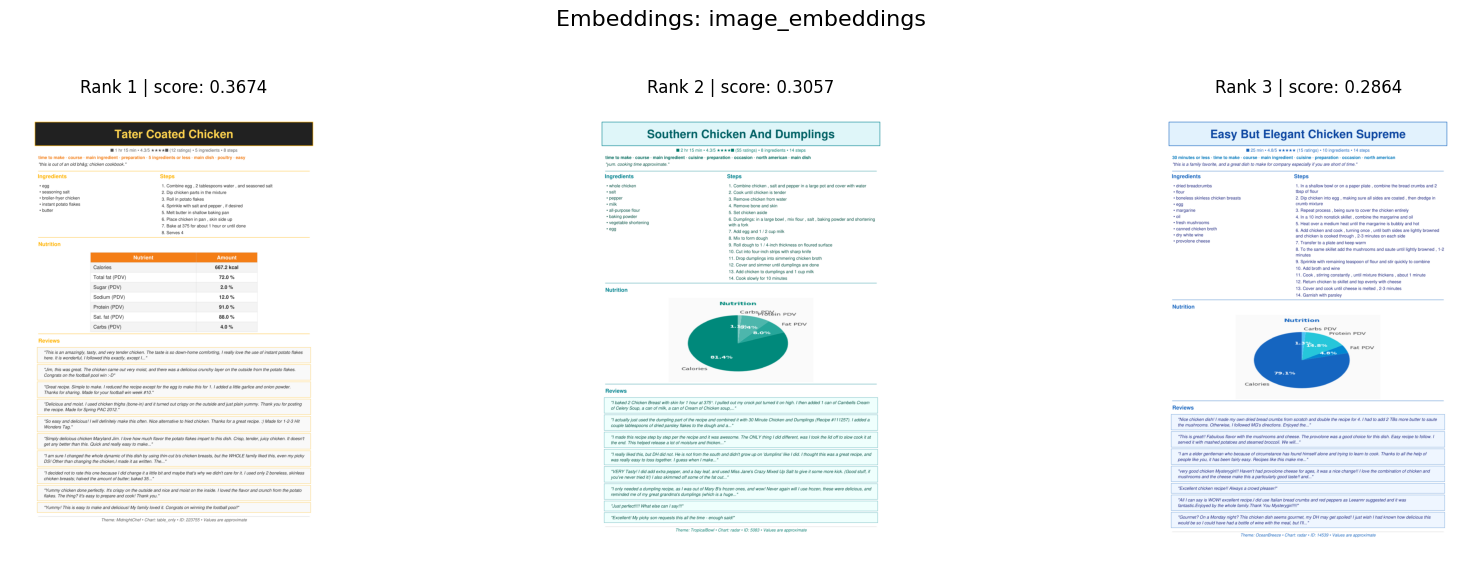

In [101]:
# for images get the top 3 recipes
top3_idx = sorted_indices[ : 3]
top3_images = [sample_100_images[i] for i in top3_idx]

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

for i, img in enumerate(top3_images):
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Rank {i+1} | score: {cos_sim_flat[sorted_indices[i]]:.4f}")

plt.suptitle(f"Embeddings: image_embeddings", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [102]:
print(f"\nQuery: {query}\n")
print(f"\nRanking (highest to lowest relevance for the modality {modality}):")
print(f"\nUsing Image embeddings")
for rank, idx in enumerate(sorted_indices[ : 3], 1):
    doc_idx = idx.item()
    sim_val = cos_sim_flat[doc_idx].item()
    if modality == "text":
        print(f"\n\nRank {rank}: cos_sim={sim_val:.4f} | Text: {sample_100_recipe_texts[doc_idx]}")
    else:  # image or image_text modality
        print(f"\n\nRank {rank}: cos_sim={sim_val:.4f} | Image: {sample_100_image_paths[doc_idx]}")
    
    print(" = " * 30)


Query: what can I make with egg, seasoning salt, broiler-fryer chicken


Ranking (highest to lowest relevance for the modality text):

Using Image embeddings


Rank 1: cos_sim=0.3674 | Text: # Tater Coated Chicken
**Recipe ID:** 223755
**Cook Time:** 75 minutes
**Rating:** 4.33/5 stars (12 reviews)

## Description
this is out of an old bh&g chicken cookbook.

## Ingredients
egg, seasoning salt, broiler-fryer chicken, instant potato flakes, butter

## Instructions
1. Combine egg , 2 tablespoons water , and seasoned salt
2. Dip chicken parts in the mixture
3. Roll in potato flakes
4. Sprinkle with salt and pepper , if desired
5. Melt butter in shallow baking pan
6. Place chicken in pan , skin side up
7. Bake at 375 for about 1 hour or until done
8. Serves 4

## Nutrition (PDV)
Calories: 667.2, Total Fat: 72.0, Sugar: 2.0, Sodium: 12.0, Protein: 91.0, Saturated Fat: 88.0

## Reviews
- Sometimes simple dishes are the best! That's so in this case. Who would have thought that chicken coated

### Now Lets check for image_text embeddings

In [103]:
# set model for query
modality , model = prepare_processor(
    modality = "text" , embedding_model = model
)

In [109]:
# query = "recipe with sausage and cherry tomatoes"

with torch.inference_mode():
    query_embedding = model.encode_queries([query])

query_embedding.shape

torch.Size([1, 2048])

In [110]:
cos_sim = _l2_normalize(query_embedding) @ _l2_normalize(tensors_dict['image_text_embeddings']).T
cos_sim.shape

torch.Size([1, 100])

In [111]:
# Flatten the similarity scores
cos_sim_flat = cos_sim.flatten()
cos_sim_flat.shape

torch.Size([100])

In [112]:
# sort the indices from highest to lowest
sorted_indices = torch.argsort(cos_sim_flat , descending = True)
sorted_indices.shape

torch.Size([100])

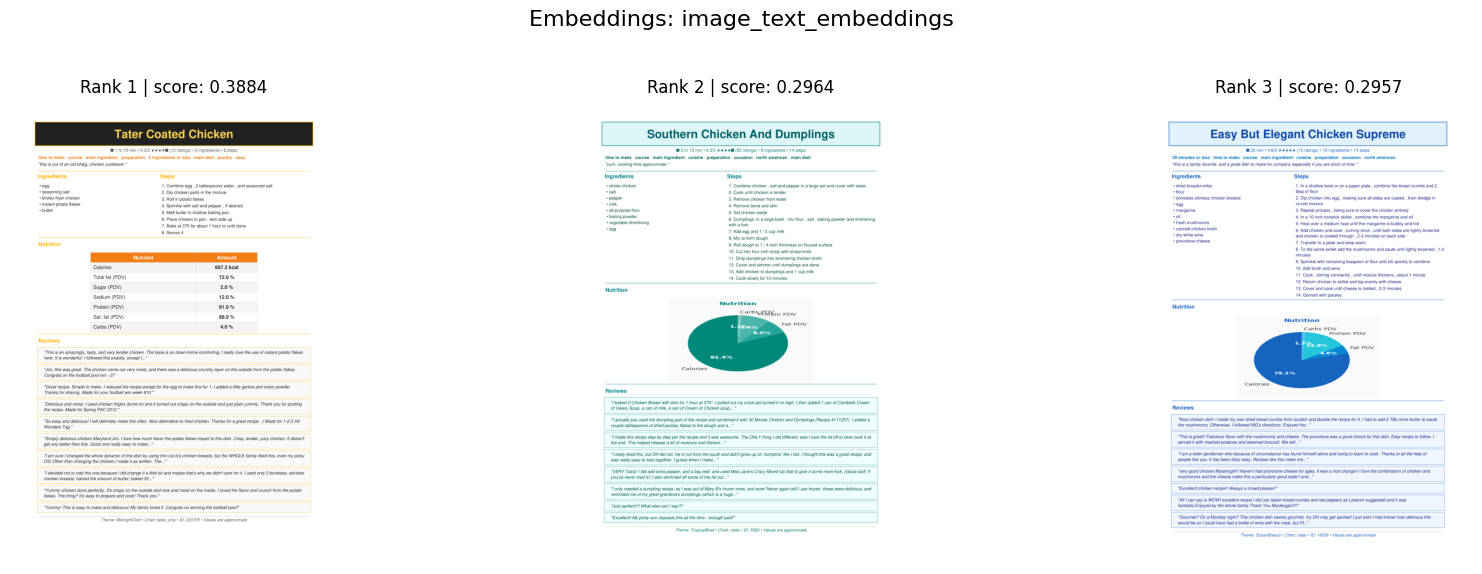

In [113]:
# for images get the top 3 recipes
top3_idx = sorted_indices[ : 3]
top3_images = [sample_100_images[i] for i in top3_idx]

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

for i, img in enumerate(top3_images):
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Rank {i+1} | score: {cos_sim_flat[sorted_indices[i]]:.4f}")

plt.suptitle(f"Embeddings: image_text_embeddings", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [82]:
top3_samples = []
top_k = 3

print(f"\nQuery: {query}\n")
print(f"\nRanking (highest to lowest relevance for the modality {modality}):")


for rank, idx in enumerate(sorted_indices[:top_k], 1):
    doc_idx = idx.item()
    sim_val = cos_sim_flat[doc_idx].item()
    
    # Retrieve the specific row from your dataframe
    row = df_sample_100.iloc[doc_idx]
    
    if modality == "text":
        print(f"\n\nRank {rank}: cos_sim={sim_val:.4f} | Text: {sample_100_recipe_texts[doc_idx]}")
    else:
        print(f"\n\nRank {rank}: cos_sim={sim_val:.4f} | Image: {sample_100_image_paths[doc_idx]}")

    top3_samples.append({
        "rank": rank,
        "score": sim_val,
        "data": row
    })
    
    print(" = " * 30)


Query: recipe with calories around 600


Ranking (highest to lowest relevance for the modality text):


Rank 1: cos_sim=0.3008 | Text: # Southwest Vegetarian Bake
**Recipe ID:** 205878
**Cook Time:** 100 minutes
**Rating:** 4.55/5 stars (49 reviews)

## Description
this is a good hearty winter meal. it can easily be made healthier by using low fat sour cream and cheese.

## Ingredients
brown rice, water, black beans, mexicorn, diced tomatoes with green chilies, salsa, sour cream, cheddar cheese, pepper, red onion, black olives, mexican blend cheese

## Instructions
1. In a large saucepan , bring rice and water to a boil
2. Reduce heat
3. Cover and simmer for 35-40 minutes , until tender
4. In a bowl , combine beans , corn , tomatoes , salsa , sour cream , cheddar , pepper and rice
5. Transfer to a 2 1 / 2 quart baking dish coated with nonstick spray
6. Sprinkle onions and olives over top
7. Bake , uncovered , at 350f for 30 minutes
8. Sprinkle mexican cheese over top
9. Bake 5-10 minu

In [83]:
# set modality to query with images
modality , model = prepare_processor(
    modality = "image",
    embedding_model = model
)

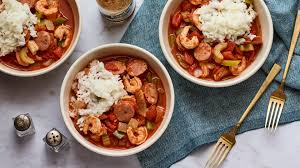

In [125]:
sample_image = load_image("data/sample/Pretty Dog Gone Easy Jambalaya Jambalaya.jpg")
sample_image

In [127]:
with torch.inference_mode():
    image_query_embedding = model.encode_documents(
        images = [sample_image]
    )

image_query_embedding.shape

torch.Size([1, 2048])

In [128]:
cos_sim = _l2_normalize(image_query_embedding) @ _l2_normalize(tensors_dict['image_text_embeddings']).T
cos_sim.shape

torch.Size([1, 100])

In [129]:
cos_sim_flat = cos_sim.flatten()
cos_sim_flat.shape

torch.Size([100])

In [130]:
# sort the indices from highest to lowest
sorted_indices = torch.argsort(cos_sim_flat , descending = True)
sorted_indices.shape

torch.Size([100])

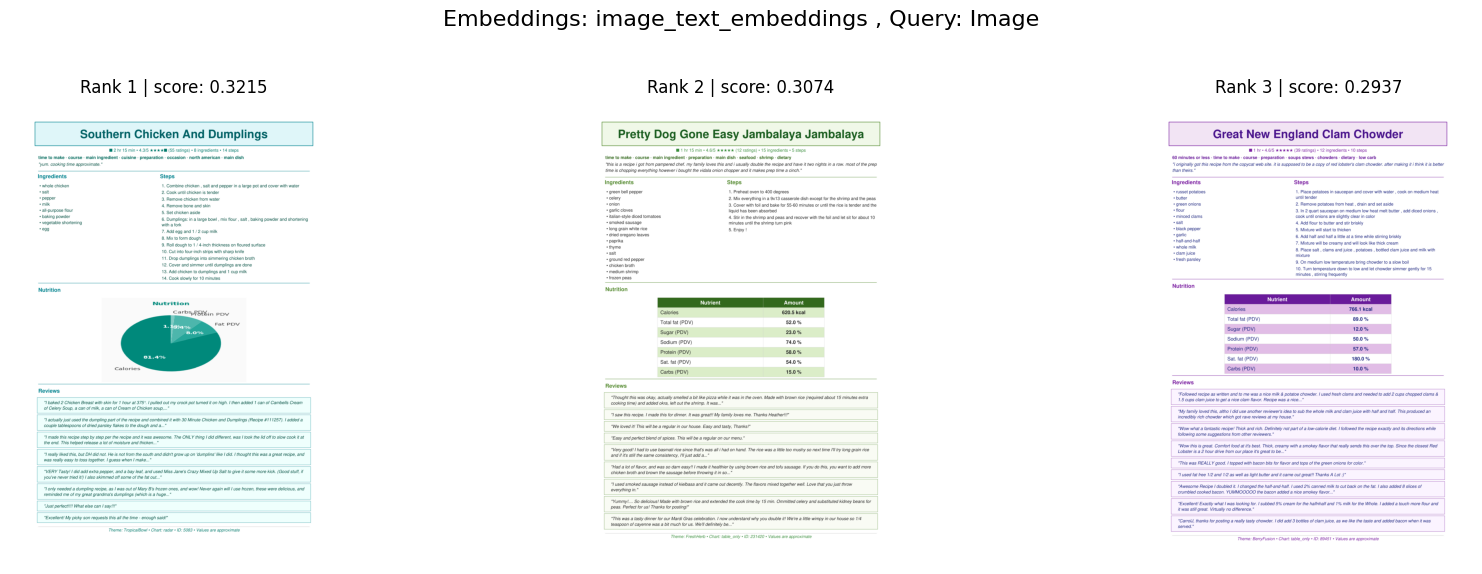

In [131]:
# for images get the top 3 recipes
top3_idx = sorted_indices[ : 3]
top3_images = [sample_100_images[i] for i in top3_idx]

plt.figure(figsize=(18, 6))

for i, img in enumerate(top3_images):
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Rank {i+1} | score: {cos_sim_flat[sorted_indices[i]]:.4f}")

plt.suptitle(f"Embeddings: image_text_embeddings , Query: Image", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()